## Neural Networks - Deep Learning
**Theodora Tzina - AEM: 10715**
### Exercise 3
#### ***Part B: Autoencoder - Next Digit Reconstruction***

This notebook implements various autoencoder architectures for MNIST next digit reconstruction.

In [6]:
import numpy as np
import time
import tensorflow as tf
import matplotlib.pyplot as plt
import dataProccessing as dp
import nextDigit as nd
from keras import layers, Model, models
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.layers import Conv2D, MaxPooling2D, UpSampling2D, Reshape, Flatten, BatchNormalization, Dropout, Concatenate
from keras.optimizers import Adam

# Set random seeds
np.random.seed(42)
tf.random.set_seed(42)

**MNIST dataset preparation**

In [7]:
# Load and normalize MNIST dataset
x_train, y_train, x_test, y_test = dp.load_mnist()

# Flatten MNIST images
x_train, x_test = dp.flatten_mnist(x_train, x_test)

# Create next digit dataset
train_inputs, train_outputs, test_inputs, test_outputs = nd.next_digit_dataset(x_train, y_train, x_test, y_test)

# Get one example of each digit from the test set
test_indices = nd.get_stratified_next_digit_samples(y_test)

Loading and Normalizing MNIST Dataset
Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)

Flattening MNIST images
Flattened training data shape: (60000, 784)
Flattened test data shape: (10000, 784)

Creating Next Digit Dataset
Creating training pairs:
Digit 0 -> 1: 5923 pairs
Digit 1 -> 2: 5958 pairs
Digit 2 -> 3: 5958 pairs
Digit 3 -> 4: 5842 pairs
Digit 4 -> 5: 5421 pairs
Digit 5 -> 6: 5421 pairs
Digit 6 -> 7: 5918 pairs
Digit 7 -> 8: 5851 pairs
Digit 8 -> 9: 5851 pairs
Digit 9 -> 0: 5923 pairs

Creating test pairs:
Digit 0 -> 1: 980 pairs
Digit 1 -> 2: 1032 pairs
Digit 2 -> 3: 1010 pairs
Digit 3 -> 4: 982 pairs
Digit 4 -> 5: 892 pairs
Digit 5 -> 6: 892 pairs
Digit 6 -> 7: 958 pairs
Digit 7 -> 8: 974 pairs
Digit 8 -> 9: 974 pairs
Digit 9 -> 0: 980 pairs

Total training pairs: 58066
Total test pairs: 9674



#### **Model 1: Dense Next Digit Autoencoder**

Dropout layers are used to prevent overfitting. No extra metrics are being used here.


Training Next Digit Model 1...
Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 39s 61ms/step - loss: 0.0756 - val_loss: 0.0745
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 35ms/step - loss: 0.0577 - val_loss: 0.0738
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0554 - val_loss: 0.0733
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0548 - val_loss: 0.0733
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0545 - val_loss: 0.0743
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 0.0543 - val_loss: 0.0732
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 24ms/step - loss: 0.0541 - val_loss: 0.0729
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.0540 - val_loss: 0.0725
Epoch 9/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 23ms/step - loss: 0.0539 - val_loss: 0.0722
Epoch 10/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0539 - val_loss: 0.0712
Epoch 11/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step - loss: 0.0538 - val_loss: 0.0718
Epoch 12

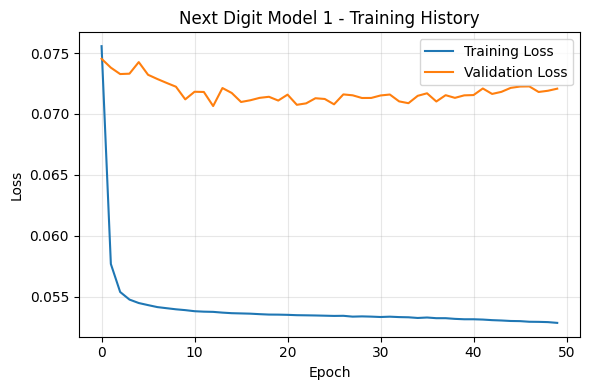

Next Digit Model 1 Final Validation Loss: 0.072078
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step


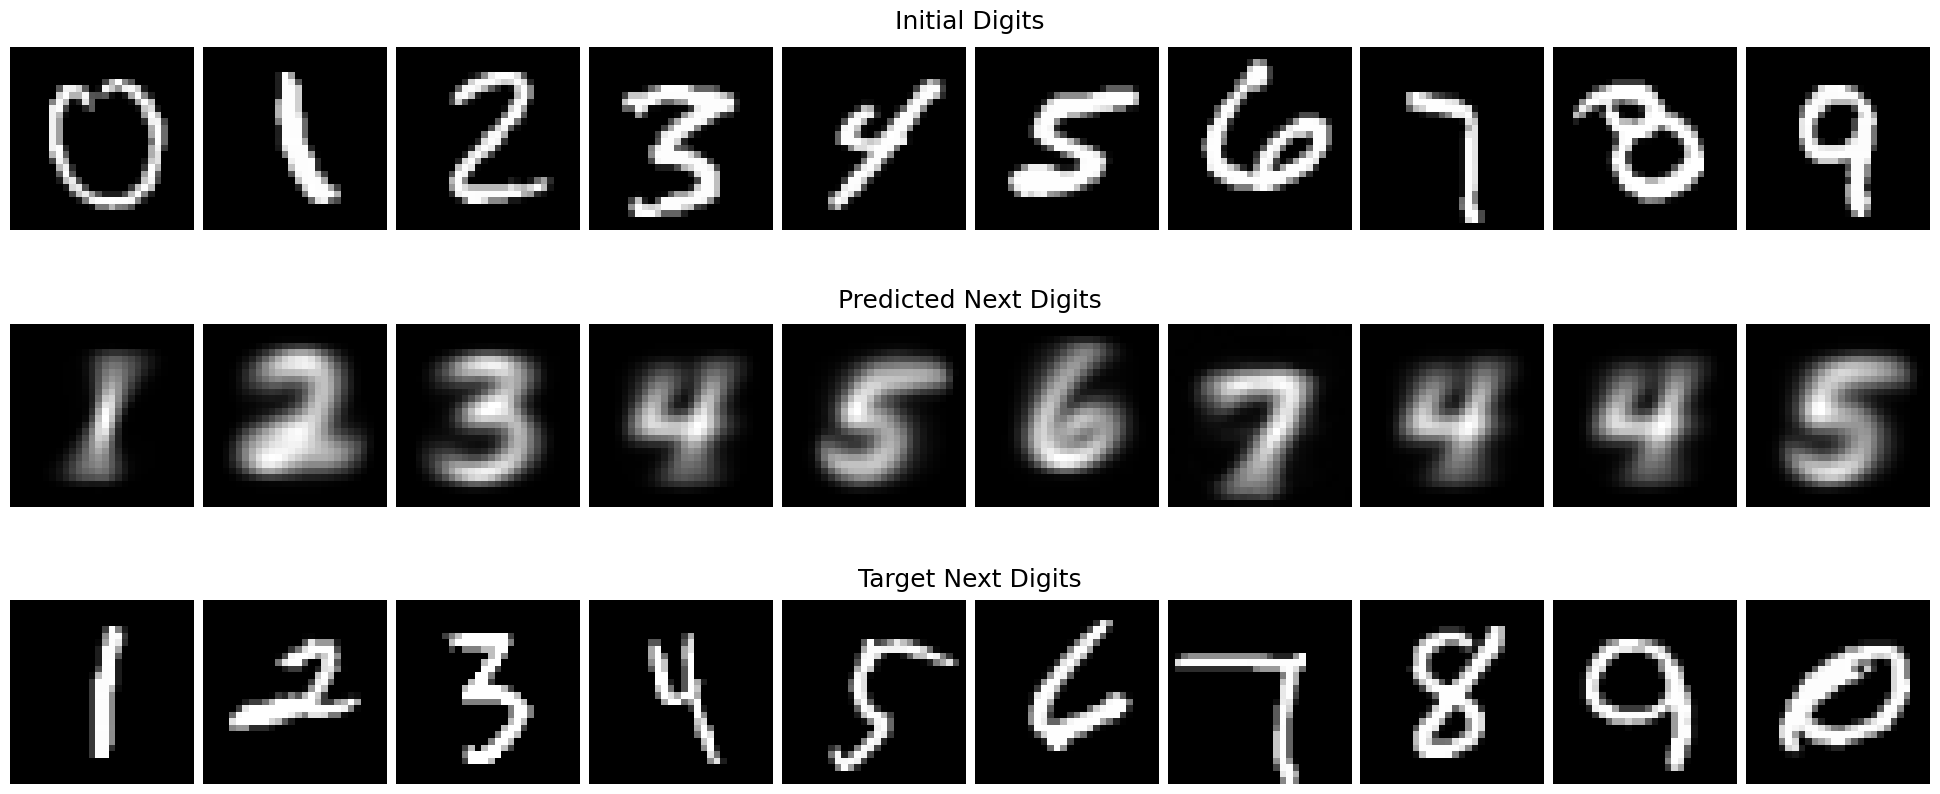

303/303 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Next Digit Model 1 Test MSE: 0.060738


In [8]:
# Model 1: Dense architecture for next digit generation
encoding_dim = 128

# Encoder
encoder_input = layers.Input(shape=(784,))
x = layers.Dense(512, activation='relu')(encoder_input)
x = layers.Dropout(0.5)(x)
x = layers.Dense(256, activation='relu')(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_nd1 = Model(encoder_input, latent, name='encoder_next_digit_1')

# Decoder
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(256, activation='relu')(decoder_input)
x = layers.Dropout(0.5)(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.5)(x)
decoder_output = layers.Dense(784, activation='sigmoid')(x)

decoder_nd1 = Model(decoder_input, decoder_output, name='decoder_next_digit_1')

# Next Digit Autoencoder Model
autoencoder_nd1 = Model(encoder_input, decoder_nd1(encoder_nd1(encoder_input)), name='autoencoder_next_digit_1')
autoencoder_nd1.compile(optimizer='adam', loss='mse')

# Train the model
print("\nTraining Next Digit Model 1...")
start_time = time.time()
history_nd1 = autoencoder_nd1.fit(train_inputs, train_outputs, epochs=50,
                                batch_size=256, validation_split=0.4, verbose=1)
train_time_nd1 = time.time() - start_time
print(f"\nNext Digit Model 1 Training Time: {train_time_nd1:.2f} seconds")

# Plot history
dp.plot_history(history_nd1, "Next Digit Model 1")

# Store validation loss
val_loss_nd1 = history_nd1.history['val_loss'][-1]
print(f"Next Digit Model 1 Final Validation Loss: {val_loss_nd1:.6f}")

# Visualize predictions
predictions_nd1 = autoencoder_nd1.predict(test_inputs[test_indices])
nd.plot_next_digit_predictions(test_inputs[test_indices], predictions_nd1, test_outputs[test_indices], n=10)

# Evaluate
mse_nd1 = dp.calculate_mse(test_outputs, autoencoder_nd1.predict(test_inputs))
print(f"Next Digit Model 1 Test MSE: {mse_nd1:.6f}")


#### **Model 2: Convolutional Next Digit Autoencoder**

Added Early Stopping. No Dropout layers for now.


Training Next Digit Model 2 (CNN) using Early Stopping...

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 102s 613ms/step - loss: 0.0809 - val_loss: 0.0853
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 101s 735ms/step - loss: 0.0542 - val_loss: 0.0852
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 108s 790ms/step - loss: 0.0535 - val_loss: 0.0836
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 93s 675ms/step - loss: 0.0533 - val_loss: 0.0816
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 90s 657ms/step - loss: 0.0531 - val_loss: 0.0796
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 91s 668ms/step - loss: 0.0528 - val_loss: 0.0815
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 87s 633ms/step - loss: 0.0525 - val_loss: 0.0809
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 88s 640ms/step - loss: 0.0520 - val_loss: 0.0796
Epoch 9/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 86s 624ms/step - loss: 0.0511 - val_loss: 0.0799
Epoch 10/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 84s 614ms/step - loss: 0.0499 - val_loss: 0.0778
Epoch 11/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 104s 

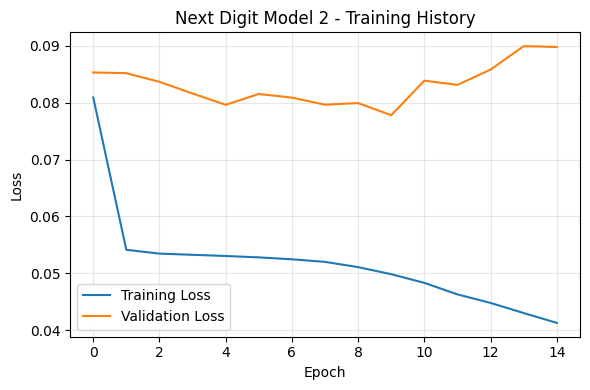

Next Digit Model 2 Final Validation Loss: 0.089768
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


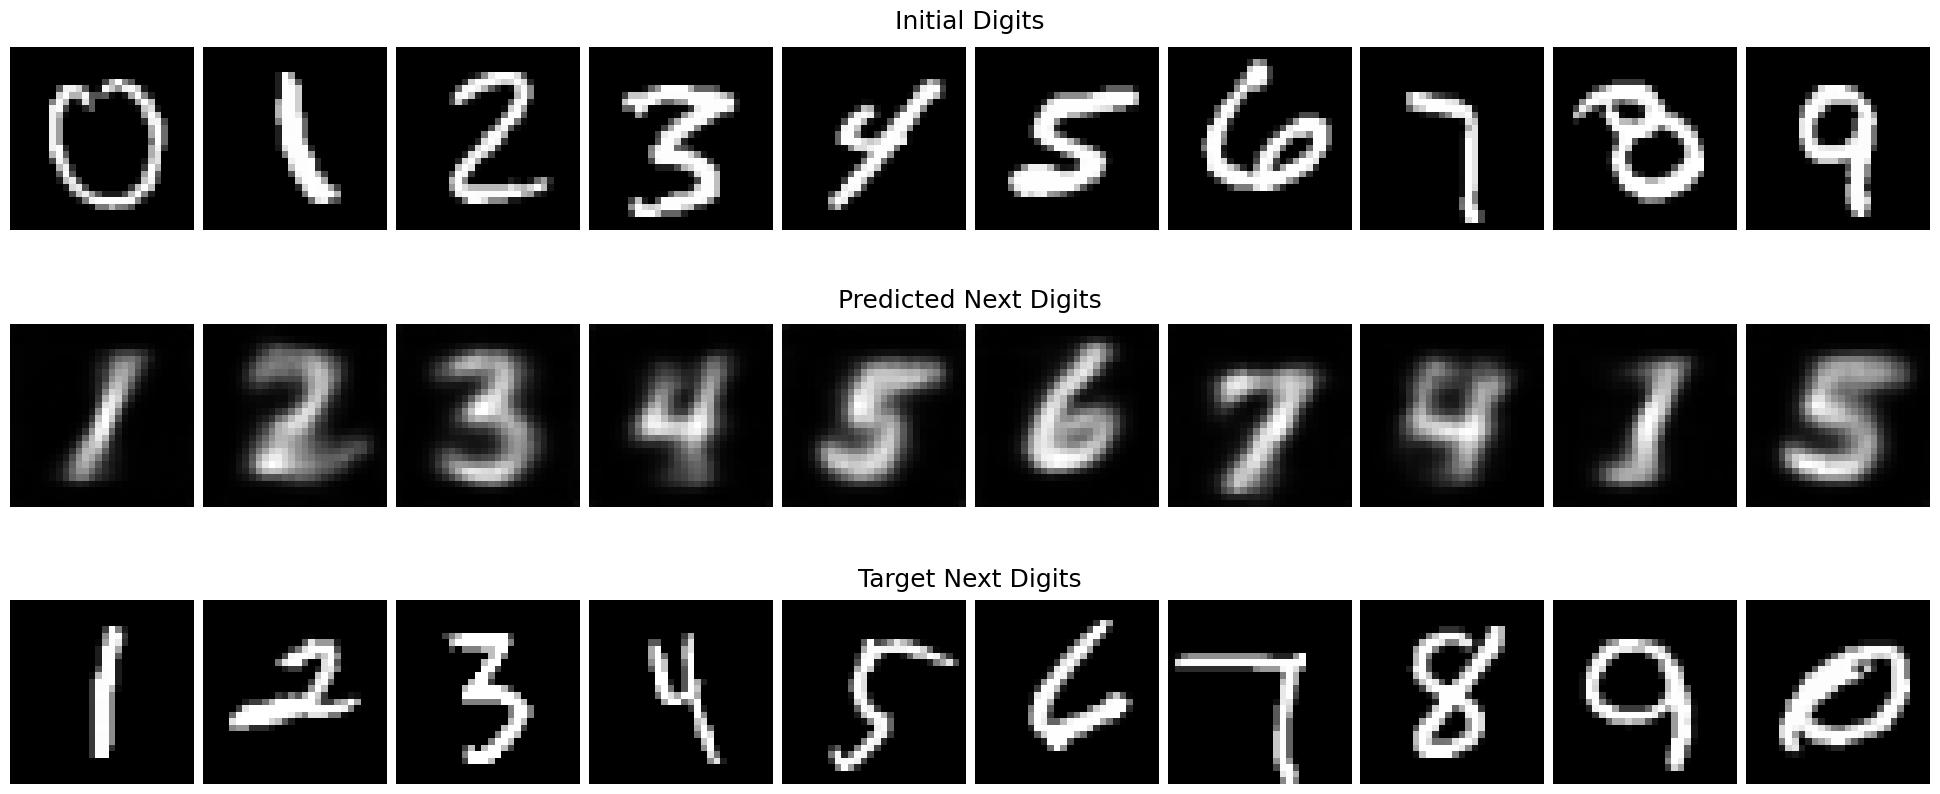

303/303 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step
Next Digit Model 2 Test MSE: 0.065650


In [13]:
# Model 2: Convolutional architecture for next digit generation
encoding_dim = 512

# Input needs to be reshaped to (28, 28, 1) for Conv2D
encoder_input = layers.Input(shape=(784,))
x = Reshape((28, 28, 1))(encoder_input)

# Encoder: Conv2D + BatchNormalization + MaxPooling
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

# Flatten and create latent representation
x = Flatten()(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_nd2 = Model(encoder_input, latent, name='encoder_next_digit_2')

# Decoder: Dense → Reshape
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(7 * 7 * 128, activation='relu')(decoder_input)
x = Reshape((7, 7, 128))(x)

# Decoder: Conv2D + BatchNormalization + UpSampling
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

x = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Flatten back to match input
decoder_output = Flatten()(x)

decoder_nd2 = Model(decoder_input, decoder_output, name='decoder_next_digit_2')

# Next Digit Autoencoder
autoencoder_nd2 = Model(encoder_input, decoder_nd2(encoder_nd2(encoder_input)), 
                        name='autoencoder_next_digit_2_CNN')

# Compile with metrics
autoencoder_nd2.compile(optimizer=Adam(learning_rate=0.001), loss='mse')

# Early Stopping callback
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,                 # Stop if no improvement for 5 epochs
    restore_best_weights=True,  # Restore weights from best epoch
    verbose=1
)

# Train with early stopping
print("\nTraining Next Digit Model 2 (CNN) using Early Stopping...\n")
start_time = time.time()
history_nd2 = autoencoder_nd2.fit(train_inputs, train_outputs, epochs=50, batch_size=256,
                                   validation_split=0.4, callbacks=[early_stop], verbose=1)
train_time_nd2 = time.time() - start_time
print(f"\nNext Digit Model 2 Training Time: {train_time_nd2:.2f} seconds")
print(f"Next Digit Model 2 Stopped at Epoch: {len(history_nd2.history['loss'])}")

# Plot history
dp.plot_history(history_nd2, "Next Digit Model 2")

# Store validation loss and metrics
val_loss_nd2 = history_nd2.history['val_loss'][-1]
print(f"Next Digit Model 2 Final Validation Loss: {val_loss_nd2:.6f}")

# Visualize predictions
predictions_nd2 = autoencoder_nd2.predict(test_inputs[test_indices])
nd.plot_next_digit_predictions(test_inputs[test_indices], predictions_nd2, 
                                test_outputs[test_indices], n=10)

# Evaluate
mse_nd2 = dp.calculate_mse(test_outputs, autoencoder_nd2.predict(test_inputs))
print(f"Next Digit Model 2 Test MSE: {mse_nd2:.6f}")


#### **Model 3: Advanced Convolutional Next Digit Autoencoder**

Convolutional Next Digit Autoencoder with Dropout layers in order to reduce overfitting. Reduced learning rate, increased Early Stopping patience and used Binary Crossentropy loss instead of MSE.


Training Next Digit Model 3 (CNN) with Dropout...

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 129s 872ms/step - loss: 0.4991 - val_loss: 0.4691
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 122s 890ms/step - loss: 0.3379 - val_loss: 0.3803
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 104s 757ms/step - loss: 0.2898 - val_loss: 0.3392
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 107s 779ms/step - loss: 0.2644 - val_loss: 0.3101
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 115s 842ms/step - loss: 0.2499 - val_loss: 0.2918
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 112s 816ms/step - loss: 0.2415 - val_loss: 0.2855
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 135s 974ms/step - loss: 0.2365 - val_loss: 0.2835
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 112s 816ms/step - loss: 0.2332 - val_loss: 0.2823
Epoch 9/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 89s 651ms/step - loss: 0.2310 - val_loss: 0.2834
Epoch 10/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 86s 631ms/step - loss: 0.2294 - val_loss: 0.2832
Epoch 11/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 93s 682m

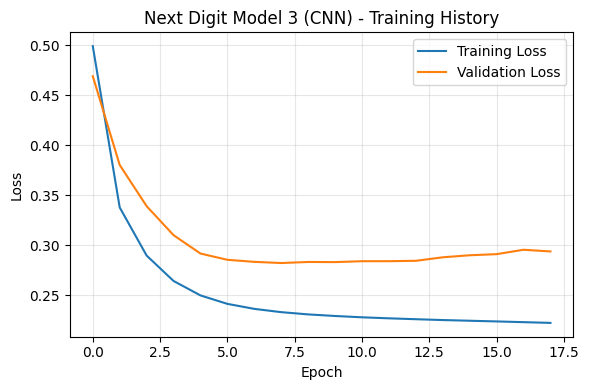

Next Digit Model 3 Final Validation Loss: 0.293896
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


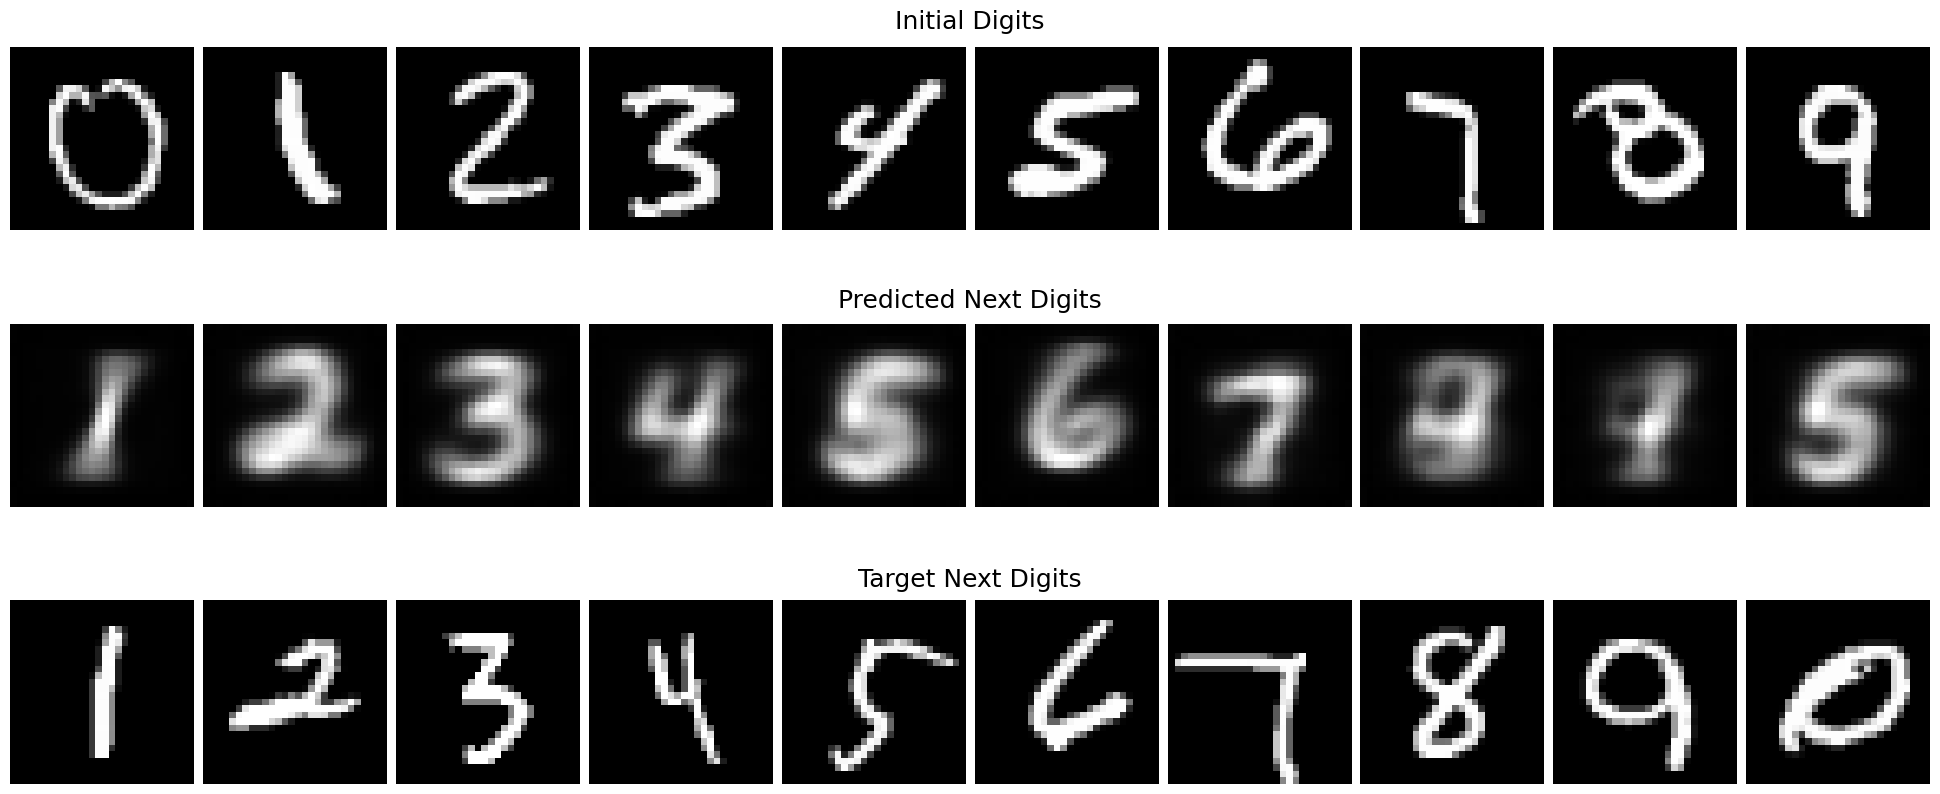

303/303 ━━━━━━━━━━━━━━━━━━━━ 10s 31ms/step
Next Digit Model 3 Test MSE: 0.060517


In [15]:
# Model 3: Convolutional architecture for next digit generation with Dropout
encoding_dim = 512

# Input needs to be reshaped to (28, 28, 1) for Conv2D
encoder_input = layers.Input(shape=(784,))
x = Reshape((28, 28, 1))(encoder_input)

# Encoder: Conv2D + BatchNormalization + Dropout + MaxPooling
x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

# Flatten and create latent representation
x = Flatten()(x)
latent = layers.Dense(encoding_dim, activation='relu')(x)

encoder_nd3 = Model(encoder_input, latent, name='encoder_next_digit_3')

# Decoder: Dense → Reshape
decoder_input = layers.Input(shape=(encoding_dim,))
x = layers.Dense(7 * 7 * 128, activation='relu')(decoder_input)
x = Reshape((7, 7, 128))(x)

# Decoder: Conv2D + BatchNormalization + Dropout + UpSampling
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Flatten back to match input
decoder_output = Flatten()(x)

decoder_nd3 = Model(decoder_input, decoder_output, name='decoder_next_digit_3')

# Next Digit Autoencoder
autoencoder_nd3 = Model(encoder_input, decoder_nd3(encoder_nd3(encoder_input)), 
                        name='autoencoder_next_digit_3_CNN')

# Compile with binary cross-entropy and reduced learning rate
autoencoder_nd3.compile(
    optimizer=Adam(learning_rate=0.0001),  # 10x smaller: 0.001 → 0.0001
    loss='binary_crossentropy',            # Changed from 'mse' to 'binary_crossentropy'
)

# Early Stopping callback with increased patience
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,                # Increased from 5 → 10
    restore_best_weights=True,
    verbose=1
)

# Train with early stopping
print("\nTraining Next Digit Model 3 (CNN) with Dropout...\n")
start_time = time.time()
history_nd3 = autoencoder_nd3.fit(train_inputs, train_outputs, epochs=50, batch_size=256,
                                  validation_split=0.4, callbacks=[early_stop], verbose=1)
train_time_nd3 = time.time() - start_time
print(f"\nNext Digit Model 3 Training Time: {train_time_nd3:.2f} seconds")
print(f"Next Digit Model 3 Stopped at Epoch: {len(history_nd3.history['loss'])}")

# Plot history
dp.plot_history(history_nd3, "Next Digit Model 3 (CNN)")

# Store validation loss and metrics
val_loss_nd3 = history_nd3.history['val_loss'][-1]
print(f"Next Digit Model 3 Final Validation Loss: {val_loss_nd3:.6f}")

# Visualize predictions
predictions_nd3 = autoencoder_nd3.predict(test_inputs[test_indices])
nd.plot_next_digit_predictions(test_inputs[test_indices], predictions_nd3, 
                                test_outputs[test_indices], n=10)

# Evaluate
mse_nd3 = dp.calculate_mse(test_outputs, autoencoder_nd3.predict(test_inputs))
print(f"Next Digit Model 3 Test MSE: {mse_nd3:.6f}")

#### **Model 4: U-Net Style Next Digit Autoencoder**

Advanced architecture with skip connections and learning rate scheduler.


Training Next Digit Model 4 (U-Net) with Skip Connections...

Epoch 1/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 100s 675ms/step - loss: 0.6481 - val_loss: 0.5945 - learning_rate: 1.0000e-04
Epoch 2/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 99s 726ms/step - loss: 0.4286 - val_loss: 1.0141 - learning_rate: 1.0000e-04
Epoch 3/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 115s 840ms/step - loss: 0.3488 - val_loss: 0.7832 - learning_rate: 1.0000e-04
Epoch 4/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 107s 783ms/step - loss: 0.3072 - val_loss: 0.4989 - learning_rate: 1.0000e-04
Epoch 5/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 109s 795ms/step - loss: 0.2830 - val_loss: 0.3681 - learning_rate: 1.0000e-04
Epoch 6/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 114s 833ms/step - loss: 0.2686 - val_loss: 0.3279 - learning_rate: 1.0000e-04
Epoch 7/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 105s 764ms/step - loss: 0.2596 - val_loss: 0.3159 - learning_rate: 1.0000e-04
Epoch 8/50
137/137 ━━━━━━━━━━━━━━━━━━━━ 100s 731ms/step - loss: 0.2536 - val_loss: 0.3112 - learning_rate: 1.000

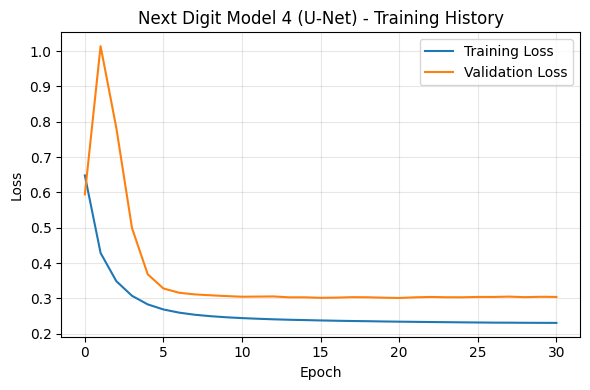


Next Digit Model 4 Final Validation Loss: 0.304047
1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step


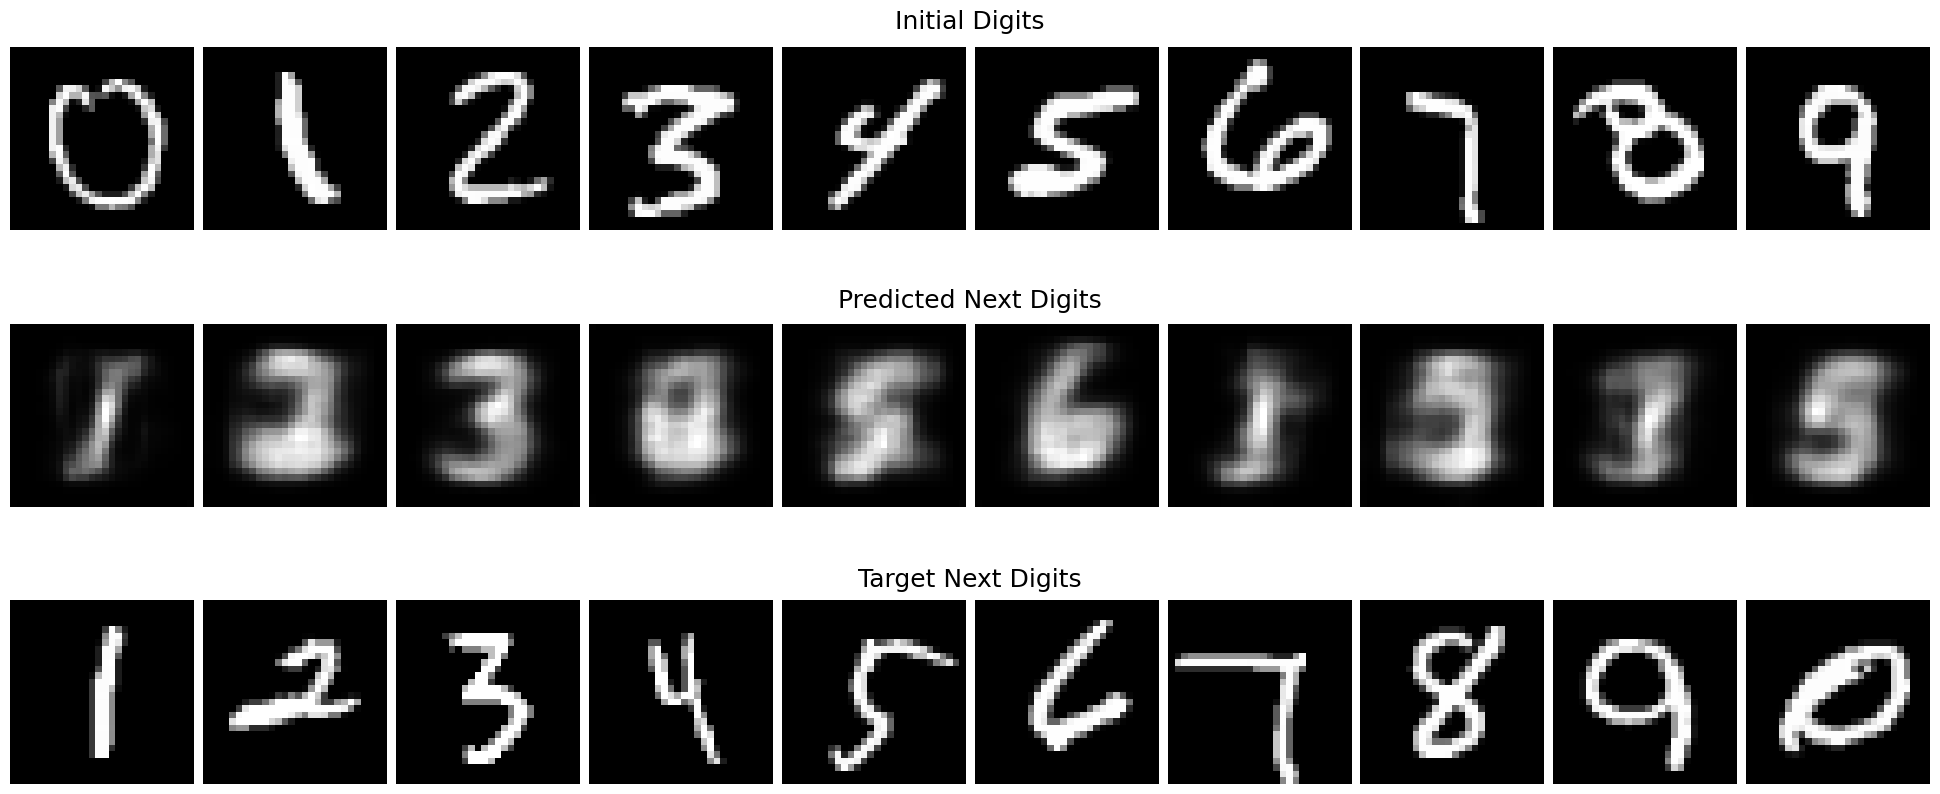

303/303 ━━━━━━━━━━━━━━━━━━━━ 22s 59ms/step
Next Digit Model 4 Test MSE: 0.064115


In [16]:
# Model 4: U-Net style architecture with Skip Connections

# Input needs to be reshaped to (28, 28, 1) for Conv2D
encoder_input = layers.Input(shape=(784,))
x1 = layers.Reshape((28, 28, 1))(encoder_input)

# Encoder (Contracting Path)
x1 = Conv2D(32, (3, 3), activation='relu', padding='same')(x1)
x1 = BatchNormalization()(x1)
x1 = Dropout(0.2)(x1)
x = MaxPooling2D((2, 2), padding='same')(x1)

x2 = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x2 = BatchNormalization()(x2)
x2 = Dropout(0.2)(x2)
x = MaxPooling2D((2, 2), padding='same')(x2)

x3 = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x3 = BatchNormalization()(x3)
x3 = Dropout(0.2)(x3)

# Decoder (Expansive Path with Skip Connections)
x = UpSampling2D((2, 2))(x3)
skip1 = Concatenate()([x, x2])  # Skip connection from encoder block 2
x = Conv2D(64, (3, 3), activation='relu', padding='same')(skip1)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = UpSampling2D((2, 2))(x)
skip2 = Concatenate()([x, x1])  # Skip connection from encoder block 1
x = Conv2D(32, (3, 3), activation='relu', padding='same')(skip2)
x = BatchNormalization()(x)
x = Dropout(0.2)(x)

x = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Flatten back to match input
decoder_output = layers.Flatten()(x)

# U-Net Autoencoder
autoencoder_nd4 = Model(encoder_input, decoder_output, name='autoencoder_next_digit_4_UNet')

# Compile with binary cross-entropy and reduced learning rate
autoencoder_nd4.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
)

# Early Stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Learning Rate Scheduler
reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,              # Reduce LR by half
    patience=5,              # Wait 5 epochs before reducing
    min_lr=0.00001,          # Don't go below 1e-5
    verbose=1
)

# Train with both Early Stopping and LR Scheduler
print("\nTraining Next Digit Model 4 (U-Net) with Skip Connections...\n")
start_time = time.time()
history_nd4 = autoencoder_nd4.fit(train_inputs, train_outputs, epochs=50, batch_size=256,
                                validation_split=0.4, callbacks=[early_stop, reduce_lr], verbose=1)
train_time_nd4 = time.time() - start_time
print(f"\nNext Digit Model 4 Training Time: {train_time_nd4:.2f} seconds")
print(f"Next Digit Model 4 Stopped at Epoch: {len(history_nd4.history['loss'])}")

# Plot history
dp.plot_history(history_nd4, "Next Digit Model 4 (U-Net)")

# Store validation metrics
val_loss_nd4 = history_nd4.history['val_loss'][-1]
print(f"\nNext Digit Model 4 Final Validation Loss: {val_loss_nd4:.6f}")

# Visualize predictions (sample every 1000th)
predictions_nd4 = autoencoder_nd4.predict(test_inputs[test_indices])
nd.plot_next_digit_predictions(test_inputs[test_indices], predictions_nd4, 
                                test_outputs[test_indices], n=10)

# Evaluate
mse_nd4 = dp.calculate_mse(test_outputs, autoencoder_nd4.predict(test_inputs))
print(f"Next Digit Model 4 Test MSE: {mse_nd4:.6f}")


#### **Model Comparison Summary**
Compare all models.

MODEL COMPARISON
Model                               MSE          Encoding     Parameters      Training Time  
----------------------------------------------------------------------------------------------------
Model 1: Dense AE                   0.060738     128          1,132,944       214.11         
Model 2: Conv AE                    0.065650     512          6,763,905       1395.70        
Model 3: Conv (BCE) AE              0.060517     512          6,763,905       1925.83        
Model 4: U-Net AE                   0.064115     6272         232,577         3904.40        



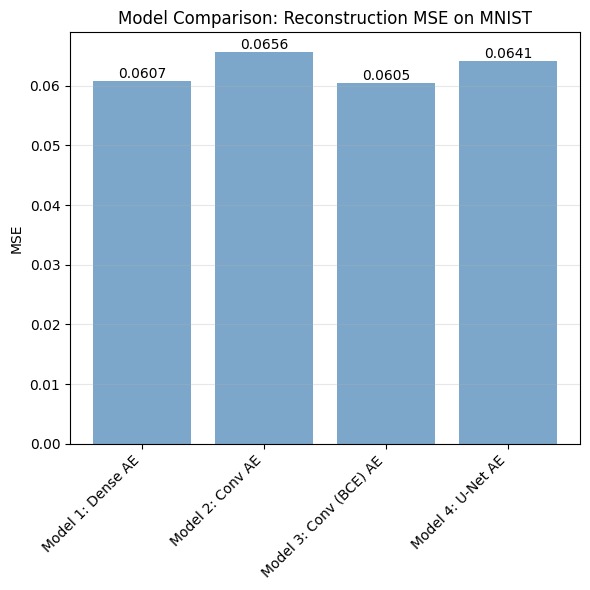

In [17]:
# Collect all next digit results
results_nd = [
    ("Model 1: Dense AE", mse_nd1, 128, autoencoder_nd1.count_params(), train_time_nd1),
    ("Model 2: Conv AE", mse_nd2, 512, autoencoder_nd2.count_params(), train_time_nd2),
    ("Model 3: Conv (BCE) AE", mse_nd3, 512, autoencoder_nd3.count_params(), train_time_nd3),
    ("Model 4: U-Net AE", mse_nd4, 7*7*128, autoencoder_nd4.count_params(), train_time_nd4)
]

# Print comparison table
dp.compare_models_table(results_nd)

# Visualize MSE comparison
model_names = [r[0] for r in results_nd]
mse_values = [r[1] for r in results_nd]

plt.figure(figsize=(6, 6))
bars = plt.bar(range(len(model_names)), mse_values, color='steelblue', alpha=0.7)
plt.xticks(range(len(model_names)), model_names, rotation=45, ha='right')
plt.ylabel('MSE')
plt.title('Model Comparison: Reconstruction MSE on MNIST')
plt.grid(axis='y', alpha=0.3)

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height, f'{mse_values[i]:.4f}', 
             ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()